# Week 2 Lab: Finance Theory in Practice

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh**

---

## Learning Objectives

By the end of this lab, you will be able to:
1. Test whether stock returns are normally distributed using histograms, QQ plots, and statistical tests
2. Calculate a stock's **beta** and **alpha** using CAPM regression
3. Plot option payoff diagrams for calls and puts
4. Explore real options chain data from Yahoo Finance
5. Build a simple two-stock portfolio and visualize the diversification benefit
6. Write effective prompts to interpret financial analysis results

---

## Part 1: Setup

In [ ]:
# Install if needed (run once, then comment out)
# !pip install yfinance pandas matplotlib plotly scipy statsmodels

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Download data we'll use throughout the lab
# Apple (our stock) and S&P 500 (the market benchmark)
apple = yf.download('AAPL', period='2y')
apple.columns = apple.columns.get_level_values(0)

spy = yf.download('SPY', period='2y')   # SPY = S&P 500 ETF
spy.columns = spy.columns.get_level_values(0)

# Calculate daily returns
apple['Return'] = apple['Close'].pct_change()
spy['Return'] = spy['Close'].pct_change()

# Calculate log returns
apple['Log_Return'] = np.log(apple['Close'] / apple['Close'].shift(1))
spy['Log_Return'] = np.log(spy['Close'] / spy['Close'].shift(1))

print(f"Apple: {len(apple)} trading days from {apple.index[0].date()} to {apple.index[-1].date()}")
print(f"SPY:   {len(spy)} trading days from {spy.index[0].date()} to {spy.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Apple: 501 trading days from 2024-02-20 to 2026-02-18
SPY:   501 trading days from 2024-02-20 to 2026-02-18


---

## Part 2: Are Stock Returns Normally Distributed?

Many financial models assume returns follow a **normal (Gaussian) distribution**. Let's test that assumption with real data.

If returns were truly normal:
- 68% would fall within 1 standard deviation of the mean
- 95% within 2 standard deviations
- 99.7% within 3 standard deviations
- A 4+ sigma event would be incredibly rare

### Histogram vs. Normal Distribution

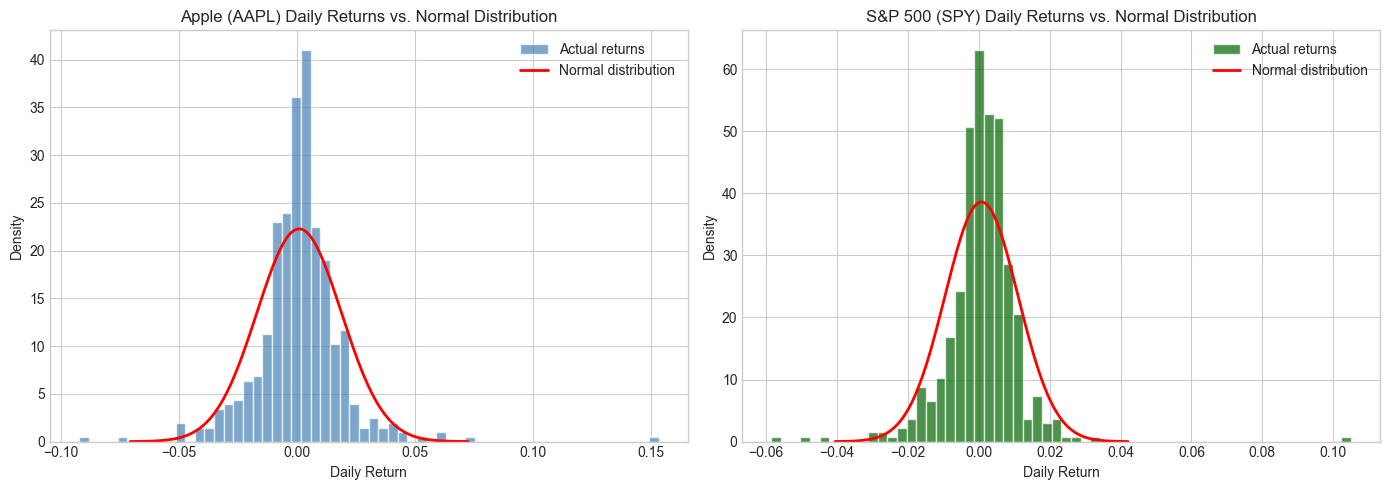

In [3]:
returns = apple['Return'].dropna()
mu = returns.mean()
sigma = returns.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Apple returns
axes[0].hist(returns, bins=60, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Actual returns')
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal distribution')
axes[0].set_title('Apple (AAPL) Daily Returns vs. Normal Distribution', fontsize=12)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: S&P 500 returns
spy_returns = spy['Return'].dropna()
mu_spy = spy_returns.mean()
sigma_spy = spy_returns.std()
axes[1].hist(spy_returns, bins=60, density=True, color='darkgreen', edgecolor='white', alpha=0.7, label='Actual returns')
x2 = np.linspace(mu_spy - 4*sigma_spy, mu_spy + 4*sigma_spy, 200)
axes[1].plot(x2, stats.norm.pdf(x2, mu_spy, sigma_spy), 'r-', linewidth=2, label='Normal distribution')
axes[1].set_title('S&P 500 (SPY) Daily Returns vs. Normal Distribution', fontsize=12)
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

**Notice:** The actual returns have:
- A **taller, narrower peak** than the normal curve (more "average" days)
- **Fatter tails** (more extreme days than the normal curve predicts)

This is called a **leptokurtic** distribution.

### QQ Plot

A **QQ (Quantile-Quantile) plot** compares the actual return distribution against what we'd expect if returns were perfectly normal. If returns were normal, all points would fall on the red diagonal line.

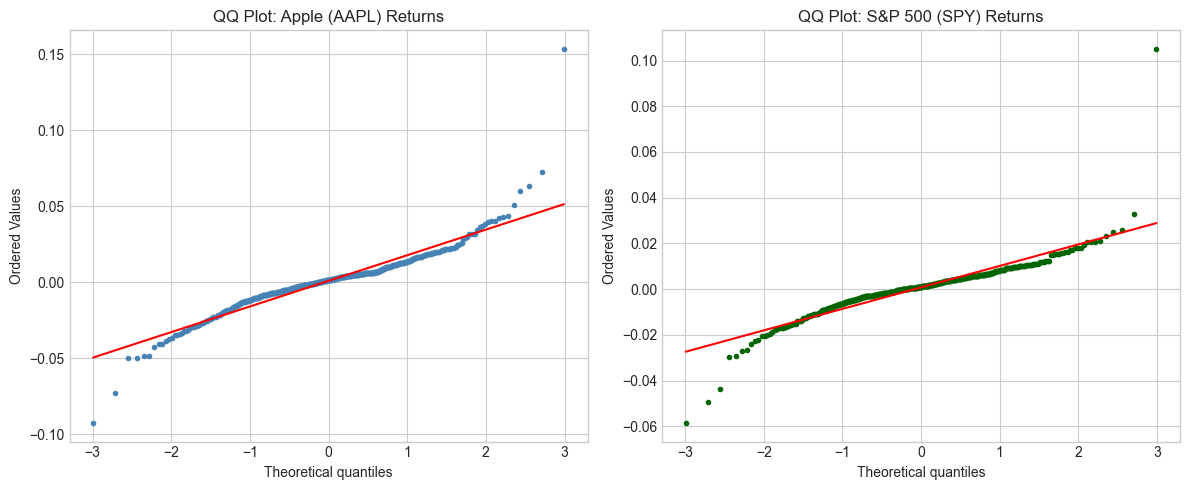

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Apple QQ plot
stats.probplot(returns, dist='norm', plot=axes[0])
axes[0].set_title('QQ Plot: Apple (AAPL) Returns', fontsize=12)
axes[0].get_lines()[0].set_color('steelblue')
axes[0].get_lines()[0].set_markersize(3)

# SPY QQ plot
stats.probplot(spy_returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot: S&P 500 (SPY) Returns', fontsize=12)
axes[1].get_lines()[0].set_color('darkgreen')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

**Interpretation:** If the dots follow the red line, returns are normally distributed. Where the dots curve *away* from the line at the edges, that's the **fat tails** — extreme returns that are more common than a normal distribution would predict.

### Statistical Tests for Normality

In [5]:
# Jarque-Bera test: tests whether skewness and kurtosis match a normal distribution
# H0 (null hypothesis): the data is normally distributed
# If p-value < 0.05, we reject H0 — the data is NOT normal

for name, ret in [('Apple (AAPL)', returns), ('S&P 500 (SPY)', spy_returns)]:
    skew = ret.skew()
    kurt = ret.kurtosis()  # excess kurtosis (normal = 0)
    jb_stat, jb_pval = stats.jarque_bera(ret)
    
    print(f"\n{name}")
    print(f"  Skewness:         {skew:.3f}  (normal = 0)")
    print(f"  Excess Kurtosis:  {kurt:.3f}  (normal = 0, fat tails > 0)")
    print(f"  Jarque-Bera stat: {jb_stat:.2f}")
    print(f"  p-value:          {jb_pval:.6f}")
    if jb_pval < 0.05:
        print(f"  Conclusion: REJECT normality (p < 0.05) — returns are NOT normally distributed")
    else:
        print(f"  Conclusion: Cannot reject normality (p >= 0.05)")


Apple (AAPL)
  Skewness:         0.909  (normal = 0)
  Excess Kurtosis:  12.890  (normal = 0, fat tails > 0)
  Jarque-Bera stat: 3455.06
  p-value:          0.000000
  Conclusion: REJECT normality (p < 0.05) — returns are NOT normally distributed

S&P 500 (SPY)
  Skewness:         1.132  (normal = 0)
  Excess Kurtosis:  23.965  (normal = 0, fat tails > 0)
  Jarque-Bera stat: 11822.05
  p-value:          0.000000
  Conclusion: REJECT normality (p < 0.05) — returns are NOT normally distributed


### Counting Extreme Events

In [6]:
# How many extreme days actually occurred vs. what a normal distribution predicts?
n_days = len(returns)

print("Extreme Events: Actual vs. Normal Distribution Prediction")
print("=" * 60)
print(f"Total trading days: {n_days}\n")

for n_sigma in [2, 3, 4]:
    # Actual count of days beyond n sigma
    actual = ((returns > mu + n_sigma * sigma) | (returns < mu - n_sigma * sigma)).sum()
    # Expected under normal distribution
    expected_pct = 2 * (1 - stats.norm.cdf(n_sigma))
    expected = expected_pct * n_days
    
    print(f"Beyond {n_sigma} sigma:")
    print(f"  Normal predicts: {expected:.1f} days")
    print(f"  Actually saw:    {actual} days")
    if expected > 0:
        print(f"  Ratio:           {actual/expected:.1f}x more than expected")
    print()

Extreme Events: Actual vs. Normal Distribution Prediction
Total trading days: 500

Beyond 2 sigma:
  Normal predicts: 22.8 days
  Actually saw:    25 days
  Ratio:           1.1x more than expected

Beyond 3 sigma:
  Normal predicts: 1.3 days
  Actually saw:    6 days
  Ratio:           4.4x more than expected

Beyond 4 sigma:
  Normal predicts: 0.0 days
  Actually saw:    4 days
  Ratio:           126.3x more than expected



**Takeaway:** Extreme events happen *far more often* than normal distribution models predict. This is why risk management based purely on normal assumptions can be dangerously wrong.

---

## Part 3: CAPM — Calculating Beta and Alpha

The **Capital Asset Pricing Model** says:

$$E(R_i) = R_f + \beta_i \times (E(R_m) - R_f)$$

To calculate beta empirically, we run a **regression** of stock returns on market returns:

$$R_{\text{stock}} = \alpha + \beta \times R_{\text{market}} + \epsilon$$

- **Beta (slope)** = how much the stock moves when the market moves
- **Alpha (intercept)** = excess return beyond what CAPM predicts

In [7]:
# Align the data: make sure we have matching dates
merged = pd.DataFrame({
    'AAPL': apple['Return'],
    'SPY': spy['Return']
}).dropna()

print(f"Matched trading days: {len(merged)}")
merged.tail()

Matched trading days: 500


,AAPL,SPY
Date,,
2026-02-11,0.006650,-0.000231
2026-02-12,-0.049982,-0.015449
2026-02-13,-0.022733,0.000705
2026-02-17,0.031668,0.001613
2026-02-18,0.001781,0.005038


In [8]:
# Run the CAPM regression
slope, intercept, r_value, p_value, std_err = stats.linregress(merged['SPY'], merged['AAPL'])

beta = slope
alpha_daily = intercept
alpha_annual = alpha_daily * 252  # annualize
r_squared = r_value ** 2

print("CAPM Regression: Apple vs. S&P 500")
print("=" * 45)
print(f"Beta:              {beta:.3f}")
print(f"Alpha (daily):     {alpha_daily:.6f} ({alpha_daily*100:.4f}%)")
print(f"Alpha (annualized): {alpha_annual:.4f} ({alpha_annual*100:.2f}%)")
print(f"R-squared:         {r_squared:.3f}")
print(f"p-value (beta):    {p_value:.2e}")
print()

if beta > 1:
    print(f"Beta = {beta:.2f} > 1: Apple is MORE volatile than the market.")
    print(f"When the market moves 1%, Apple tends to move {beta:.2f}%.")
elif beta < 1:
    print(f"Beta = {beta:.2f} < 1: Apple is LESS volatile than the market.")
    print(f"When the market moves 1%, Apple tends to move {beta:.2f}%.")
else:
    print(f"Beta ≈ 1: Apple moves roughly in line with the market.")

print(f"\nR-squared = {r_squared:.3f}: The market explains {r_squared*100:.1f}% of Apple's return variation.")
print(f"The remaining {(1-r_squared)*100:.1f}% is company-specific (idiosyncratic) risk.")

CAPM Regression: Apple vs. S&P 500
Beta:              1.169
Alpha (daily):     0.000054 (0.0054%)
Alpha (annualized): 0.0135 (1.35%)
R-squared:         0.455
p-value (beta):    1.26e-67

Beta = 1.17 > 1: Apple is MORE volatile than the market.
When the market moves 1%, Apple tends to move 1.17%.

R-squared = 0.455: The market explains 45.5% of Apple's return variation.
The remaining 54.5% is company-specific (idiosyncratic) risk.


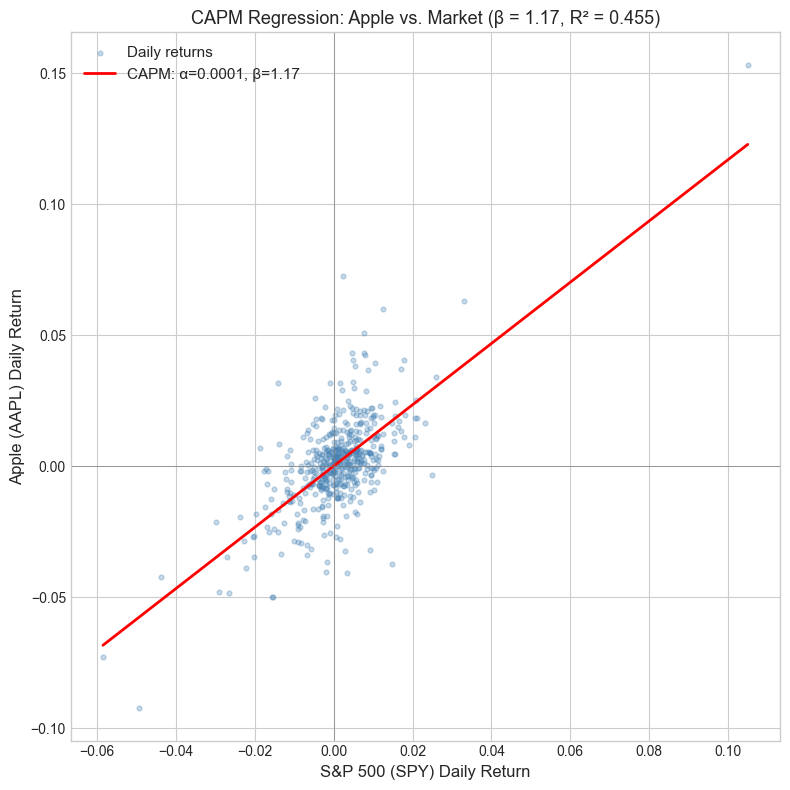

In [9]:
# Scatter plot with regression line
plt.figure(figsize=(8, 8))
plt.scatter(merged['SPY'], merged['AAPL'], alpha=0.3, s=12, color='steelblue', label='Daily returns')

# Regression line
x_line = np.linspace(merged['SPY'].min(), merged['SPY'].max(), 100)
y_line = intercept + beta * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'CAPM: α={alpha_daily:.4f}, β={beta:.2f}')

plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.xlabel('S&P 500 (SPY) Daily Return', fontsize=12)
plt.ylabel('Apple (AAPL) Daily Return', fontsize=12)
plt.title(f'CAPM Regression: Apple vs. Market (β = {beta:.2f}, R² = {r_squared:.3f})', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Security Market Line

Let's calculate beta for several stocks and plot the **Security Market Line** (SML) — the relationship between beta and expected return.

In [10]:
# Calculate beta and return for several stocks
tickers = ['AAPL', 'MSFT', 'TSLA', 'JNJ', 'XOM', 'NVDA', 'JPM', 'NEE']
stock_data = yf.download(tickers, period='2y')['Close']

# SPY returns as market benchmark
spy_ret = spy['Return'].dropna()

results = []
for ticker in tickers:
    stock_ret = stock_data[ticker].pct_change().dropna()
    # Align dates
    common = pd.DataFrame({'stock': stock_ret, 'market': spy_ret}).dropna()
    slope_i, intercept_i, _, _, _ = stats.linregress(common['market'], common['stock'])
    ann_return = common['stock'].mean() * 252
    results.append({'Ticker': ticker, 'Beta': slope_i, 'Ann. Return': ann_return})

sml_df = pd.DataFrame(results)
print(sml_df.to_string(index=False))

[*********************100%***********************]  8 of 8 completed

Ticker     Beta  Ann. Return
  AAPL 1.168859     0.233929
  MSFT 0.962926     0.031124
  TSLA 2.288538     0.574365
   JNJ 0.012294     0.264475
   XOM 0.423509     0.251626
  NVDA 2.110011     0.631919
   JPM 0.934422     0.325672
   NEE 0.299549     0.305174


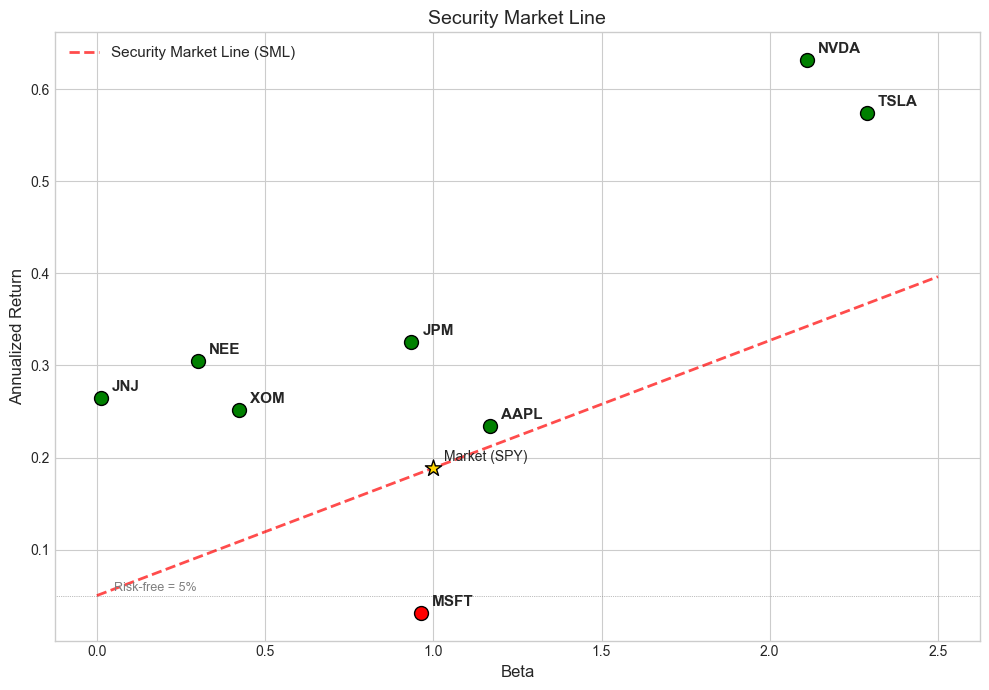

Green dots = ABOVE the SML (positive alpha — outperforming for their risk level)
Red dots   = BELOW the SML (negative alpha — underperforming for their risk level)


In [11]:
# Plot the Security Market Line
risk_free = 0.05
market_return = spy_ret.mean() * 252

plt.figure(figsize=(10, 7))

# SML line: from risk-free rate through the market portfolio (beta=1)
beta_range = np.linspace(0, 2.5, 100)
sml_line = risk_free + beta_range * (market_return - risk_free)
plt.plot(beta_range, sml_line, 'r--', linewidth=2, label='Security Market Line (SML)', alpha=0.7)

# Plot each stock
for _, row in sml_df.iterrows():
    color = 'green' if row['Ann. Return'] > risk_free + row['Beta'] * (market_return - risk_free) else 'red'
    plt.scatter(row['Beta'], row['Ann. Return'], s=100, color=color, zorder=5, edgecolor='black')
    plt.annotate(row['Ticker'], (row['Beta'], row['Ann. Return']),
                 textcoords='offset points', xytext=(8, 5), fontsize=11, fontweight='bold')

# Market portfolio
plt.scatter(1.0, market_return, s=150, color='gold', zorder=5, edgecolor='black', marker='*')
plt.annotate('Market (SPY)', (1.0, market_return), textcoords='offset points', xytext=(8, 5), fontsize=10)

plt.xlabel('Beta', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title('Security Market Line', fontsize=14)
plt.legend(fontsize=11)
plt.axhline(y=risk_free, color='gray', linewidth=0.5, linestyle=':')
plt.text(0.05, risk_free + 0.005, f'Risk-free = {risk_free:.0%}', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

print("Green dots = ABOVE the SML (positive alpha — outperforming for their risk level)")
print("Red dots   = BELOW the SML (negative alpha — underperforming for their risk level)")

---

## Part 4: Options — Payoff Diagrams

An **option** gives you the right (not obligation) to buy or sell a stock at a specific price.

- **Call option**: Right to **buy** at the strike price
- **Put option**: Right to **sell** at the strike price

Let's visualize the payoff diagrams.

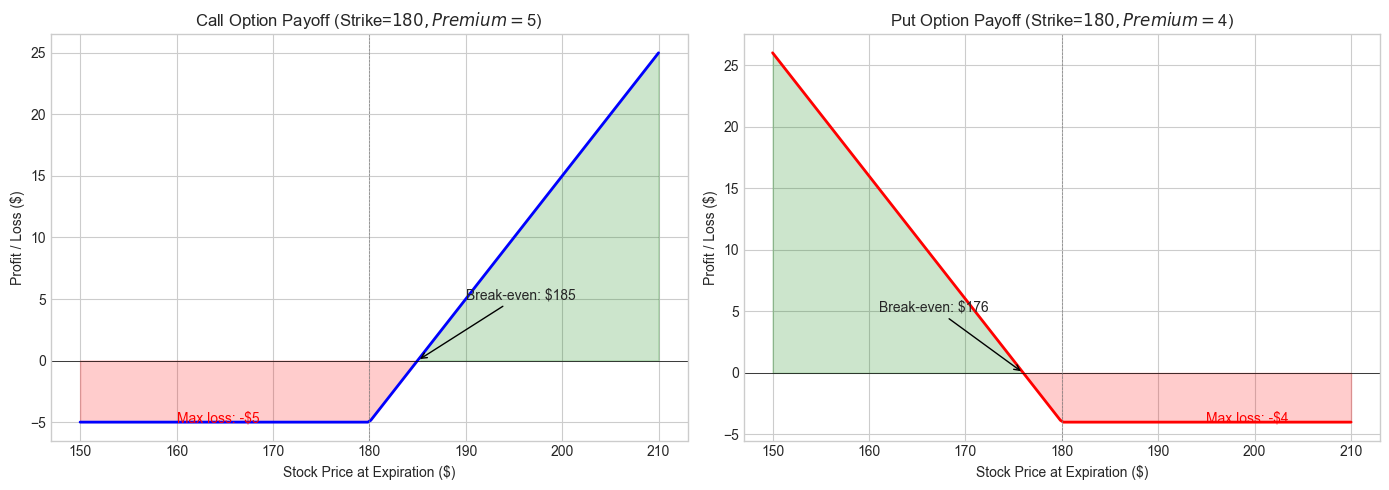

In [12]:
# Option payoff diagrams
strike = 180       # Strike price
call_premium = 5   # Cost of buying the call
put_premium = 4    # Cost of buying the put

# Range of possible stock prices at expiration
prices = np.linspace(150, 210, 200)

# Call payoff: max(Stock - Strike, 0) - Premium
call_payoff = np.maximum(prices - strike, 0) - call_premium

# Put payoff: max(Strike - Stock, 0) - Premium
put_payoff = np.maximum(strike - prices, 0) - put_premium

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Call option
axes[0].plot(prices, call_payoff, 'b-', linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axvline(x=strike, color='gray', linewidth=0.5, linestyle='--')
axes[0].fill_between(prices, call_payoff, 0, where=(call_payoff > 0), alpha=0.2, color='green')
axes[0].fill_between(prices, call_payoff, 0, where=(call_payoff < 0), alpha=0.2, color='red')
axes[0].set_title(f'Call Option Payoff (Strike=${strike}, Premium=${call_premium})', fontsize=12)
axes[0].set_xlabel('Stock Price at Expiration ($)')
axes[0].set_ylabel('Profit / Loss ($)')
axes[0].annotate(f'Break-even: ${strike + call_premium}', xy=(strike + call_premium, 0),
                 xytext=(strike + call_premium + 5, 5), fontsize=10,
                 arrowprops=dict(arrowstyle='->', color='black'))
axes[0].annotate(f'Max loss: -${call_premium}', xy=(160, -call_premium),
                 fontsize=10, color='red')

# Put option
axes[1].plot(prices, put_payoff, 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axvline(x=strike, color='gray', linewidth=0.5, linestyle='--')
axes[1].fill_between(prices, put_payoff, 0, where=(put_payoff > 0), alpha=0.2, color='green')
axes[1].fill_between(prices, put_payoff, 0, where=(put_payoff < 0), alpha=0.2, color='red')
axes[1].set_title(f'Put Option Payoff (Strike=${strike}, Premium=${put_premium})', fontsize=12)
axes[1].set_xlabel('Stock Price at Expiration ($)')
axes[1].set_ylabel('Profit / Loss ($)')
axes[1].annotate(f'Break-even: ${strike - put_premium}', xy=(strike - put_premium, 0),
                 xytext=(strike - put_premium - 15, 5), fontsize=10,
                 arrowprops=dict(arrowstyle='->', color='black'))
axes[1].annotate(f'Max loss: -${put_premium}', xy=(195, -put_premium),
                 fontsize=10, color='red')

plt.tight_layout()
plt.show()

**Key observations:**
- **Call**: You profit when the stock goes *above* the strike + premium. Max loss = the premium.
- **Put**: You profit when the stock goes *below* the strike - premium. Max loss = the premium.
- Both have the characteristic **hockey stick** shape — asymmetric risk/reward.
- This asymmetry is why options are powerful for hedging and speculation.

### Combined Strategies: Protective Put (Insurance)

What if you own Apple stock and buy a put option to protect against a crash? This is called a **protective put** — it's like buying insurance on your stock.

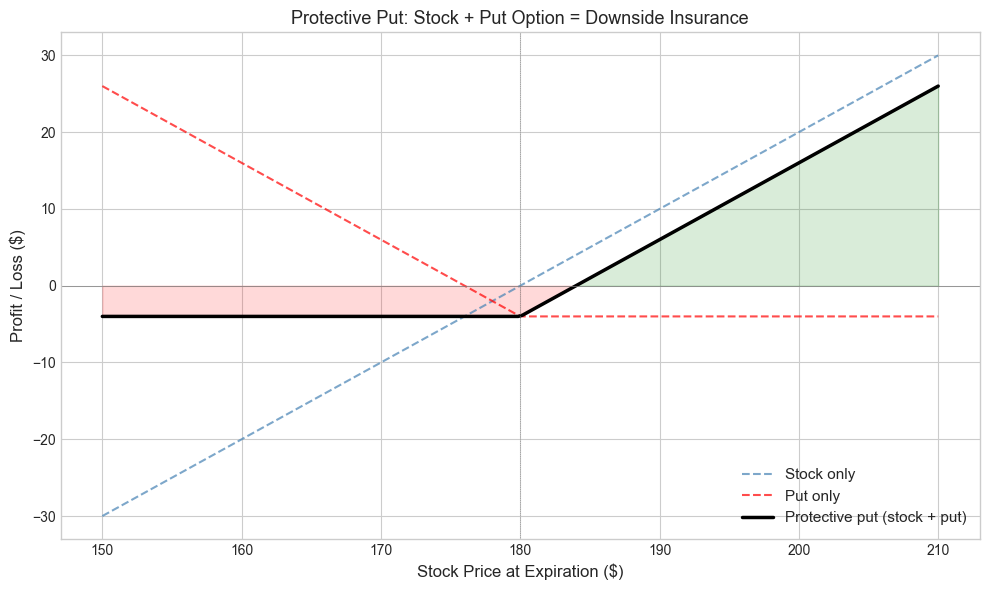

With a protective put, your max loss is limited to $4 (the put premium).
But you keep all the upside above $184.
The cost: you give up $4 of profit in the good scenario.


In [15]:
# You own the stock (bought at $180) AND you buy a put at strike $180
stock_payoff = prices - 180  # P&L from owning the stock
protective_put = stock_payoff + put_payoff  # stock + put combined

plt.figure(figsize=(10, 6))
plt.plot(prices, stock_payoff, '--', color='steelblue', linewidth=1.5, label='Stock only', alpha=0.7)
plt.plot(prices, put_payoff, '--', color='red', linewidth=1.5, label='Put only', alpha=0.7)
plt.plot(prices, protective_put, 'k-', linewidth=2.5, label='Protective put (stock + put)')
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=strike, color='gray', linewidth=0.5, linestyle=':')
plt.fill_between(prices, protective_put, 0, where=(protective_put > 0), alpha=0.15, color='green')
plt.fill_between(prices, protective_put, 0, where=(protective_put < 0), alpha=0.15, color='red')
plt.xlabel('Stock Price at Expiration ($)', fontsize=12)
plt.ylabel('Profit / Loss ($)', fontsize=12)
plt.title('Protective Put: Stock + Put Option = Downside Insurance', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"With a protective put, your max loss is limited to ${put_premium} (the put premium).")
print(f"But you keep all the upside above ${strike + put_premium}.")
print(f"The cost: you give up ${put_premium} of profit in the good scenario.")

### Exploring Real Options Data

Yahoo Finance provides real options chain data. Let's look at what options are actually available for Apple.

In [16]:
# Get Apple's available options expiration dates
aapl = yf.Ticker('AAPL')
expirations = aapl.options
print("Available expiration dates:")
for i, exp in enumerate(expirations[:8]):  # show first 8
    print(f"  {i+1}. {exp}")
print(f"  ... and {len(expirations) - 8} more")

Available expiration dates:
  1. 2026-02-20
  2. 2026-02-23
  3. 2026-02-25
  4. 2026-02-27
  5. 2026-03-06
  6. 2026-03-13
  7. 2026-03-20
  8. 2026-03-27
  ... and 15 more


In [17]:
# Get the options chain for the nearest expiration
nearest_exp = expirations[0]
opt_chain = aapl.option_chain(nearest_exp)

print(f"Options chain for AAPL expiring {nearest_exp}")
print(f"\nCALL options (right to BUY):")
# Show calls near the current stock price
current_price = apple['Close'].iloc[-1]
calls = opt_chain.calls
near_money_calls = calls[(calls['strike'] >= current_price * 0.95) & 
                         (calls['strike'] <= current_price * 1.05)]
print(near_money_calls[['strike', 'lastPrice', 'bid', 'ask', 'volume', 'impliedVolatility']].to_string(index=False))

print(f"\nPUT options (right to SELL):")
puts = opt_chain.puts
near_money_puts = puts[(puts['strike'] >= current_price * 0.95) & 
                       (puts['strike'] <= current_price * 1.05)]
print(near_money_puts[['strike', 'lastPrice', 'bid', 'ask', 'volume', 'impliedVolatility']].to_string(index=False))

Options chain for AAPL expiring 2026-02-20

CALL options (right to BUY):
 strike  lastPrice   bid   ask  volume  impliedVolatility
  252.5      13.15 11.90 12.20    3502           0.456060
  255.0      10.47  9.60 10.00    4546           0.458013
  257.5       7.70  7.30  7.75    4124           0.419928
  260.0       5.25  5.20  5.40    4185           0.346442
  262.5       3.40  3.35  3.50    9050           0.316901
  265.0       1.94  1.92  1.97   23091           0.291755
  267.5       0.97  0.93  0.97   21871           0.279548
  270.0       0.42  0.39  0.42   23513           0.274910
  272.5       0.17  0.16  0.18    7227           0.281257
  275.0       0.09  0.08  0.09   12551           0.299812
  277.5       0.05  0.04  0.05    4942           0.322272

PUT options (right to SELL):
 strike  lastPrice   bid   ask  volume  impliedVolatility
  252.5       0.21  0.21  0.22  1554.0           0.408209
  255.0       0.31  0.32  0.35  3698.0           0.380866
  257.5       0.55  0.52  0

**Reading the options chain:**
- **strike**: The price at which you can buy/sell the stock
- **lastPrice**: What the option last traded at
- **bid/ask**: Current buy and sell prices (just like stocks!)
- **volume**: How many contracts traded today
- **impliedVolatility**: The market's expectation of future volatility, *derived from the option price*

Notice that **implied volatility** is embedded in option prices — this is one of the most important signals in finance. AI models can analyze implied volatility patterns to forecast future market movements.

---

## Part 5: Portfolio Diversification

What happens when you combine two stocks in a portfolio? If they're not perfectly correlated, the portfolio risk is **less** than the average of the two stocks' risks.

This is diversification — the "free lunch" of finance.

In [18]:
# Download two stocks
pair = yf.download(['AAPL', 'XOM'], period='2y')['Close']
pair_returns = pair.pct_change().dropna()

corr = pair_returns['AAPL'].corr(pair_returns['XOM'])
print(f"Correlation between Apple and ExxonMobil: {corr:.3f}")
print("(Lower correlation = more diversification benefit)\n")

# Individual stock stats (annualized)
for ticker in ['AAPL', 'XOM']:
    ret = pair_returns[ticker].mean() * 252
    vol = pair_returns[ticker].std() * np.sqrt(252)
    print(f"{ticker}: Return = {ret:.2%}, Volatility = {vol:.2%}")

[*********************100%***********************]  2 of 2 completed

Correlation between Apple and ExxonMobil: 0.237
(Lower correlation = more diversification benefit)

AAPL: Return = 23.39%, Volatility = 28.43%
XOM: Return = 25.16%, Volatility = 22.25%


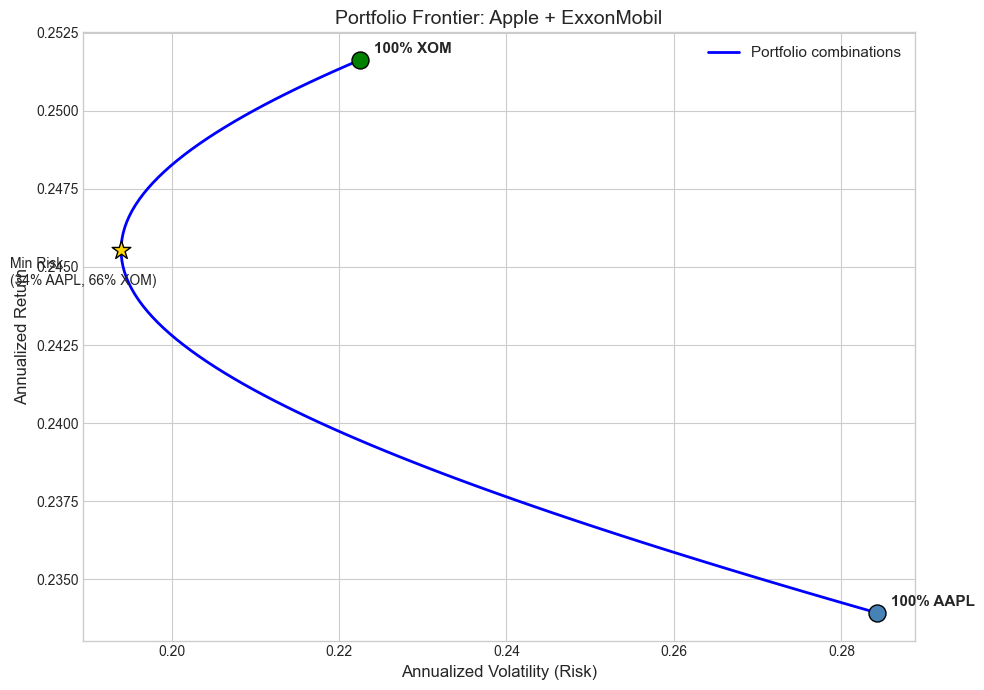

Minimum risk portfolio: 34% Apple + 66% ExxonMobil
  Return:     24.55%
  Volatility: 19.40%

Notice: the minimum risk portfolio has LESS volatility than either stock alone!
This is the diversification benefit.


In [19]:
# Vary the portfolio weights and compute risk-return for each
weights_aapl = np.linspace(0, 1, 100)

mu_aapl = pair_returns['AAPL'].mean() * 252
mu_xom = pair_returns['XOM'].mean() * 252
vol_aapl = pair_returns['AAPL'].std() * np.sqrt(252)
vol_xom = pair_returns['XOM'].std() * np.sqrt(252)

port_returns = []
port_vols = []

for w in weights_aapl:
    # Portfolio return = weighted average of individual returns
    p_ret = w * mu_aapl + (1 - w) * mu_xom
    
    # Portfolio volatility — THIS is where diversification happens
    # It's NOT just the weighted average of volatilities
    p_vol = np.sqrt(
        (w * vol_aapl)**2 + 
        ((1 - w) * vol_xom)**2 + 
        2 * w * (1 - w) * vol_aapl * vol_xom * corr
    )
    
    port_returns.append(p_ret)
    port_vols.append(p_vol)

# Find the minimum volatility portfolio
min_vol_idx = np.argmin(port_vols)
min_vol_w = weights_aapl[min_vol_idx]

plt.figure(figsize=(10, 7))
plt.plot(port_vols, port_returns, 'b-', linewidth=2, label='Portfolio combinations')

# Mark individual stocks
plt.scatter(vol_aapl, mu_aapl, s=150, color='steelblue', zorder=5, edgecolor='black')
plt.annotate('100% AAPL', (vol_aapl, mu_aapl), textcoords='offset points', xytext=(10, 5), fontsize=11, fontweight='bold')

plt.scatter(vol_xom, mu_xom, s=150, color='green', zorder=5, edgecolor='black')
plt.annotate('100% XOM', (vol_xom, mu_xom), textcoords='offset points', xytext=(10, 5), fontsize=11, fontweight='bold')

# Mark minimum volatility portfolio
plt.scatter(port_vols[min_vol_idx], port_returns[min_vol_idx], s=200, color='gold', zorder=5, 
            edgecolor='black', marker='*')
plt.annotate(f'Min Risk\n({min_vol_w:.0%} AAPL, {1-min_vol_w:.0%} XOM)', 
             (port_vols[min_vol_idx], port_returns[min_vol_idx]),
             textcoords='offset points', xytext=(-80, -25), fontsize=10)

plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title('Portfolio Frontier: Apple + ExxonMobil', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Minimum risk portfolio: {min_vol_w:.0%} Apple + {1-min_vol_w:.0%} ExxonMobil")
print(f"  Return:     {port_returns[min_vol_idx]:.2%}")
print(f"  Volatility: {port_vols[min_vol_idx]:.2%}")
print(f"\nNotice: the minimum risk portfolio has LESS volatility than either stock alone!")
print(f"This is the diversification benefit.")

**Key insight:** The curved line shows all possible combinations of the two stocks. The curve bends to the *left* of a straight line between the two stocks — meaning you can get *less risk* than a simple average by combining them. The lower the correlation, the more the curve bends left (more diversification benefit).

This is a preview of **Mean-Variance Portfolio Theory** (Markowitz). With many stocks, you'd get an **efficient frontier** — the boundary of the best possible risk-return combinations.

---

## Part 6: Your Turn — Exercises

### Exercise 1: CAPM for a Stock of Your Choice

Pick a stock and calculate its beta and alpha using CAPM regression against SPY.

Some ideas: `TSLA` (high beta?), `JNJ` (low beta?), `NVDA` (tech growth), `GS` (financial sector)

[*********************100%***********************]  1 of 1 completed


Matched trading days: 500

CAPM Regression: Tesla (TSLA) vs. S&P 500
Beta:               2.289
Alpha (daily):      0.000567 (0.0567%)
Alpha (annualized): 0.1428 (14.28%)
R-squared:          0.356
p-value (beta):     1.79e-49

Beta = 2.29 > 1: Tesla is MORE volatile than the market.
When the market moves 1%, Tesla tends to move 2.29%.

R-squared = 0.356: The market explains 35.6% of Tesla's return variation.
The remaining 64.4% is company-specific (idiosyncratic) risk.

Positive alpha of 14.28% per year — Tesla earned excess returns beyond CAPM.


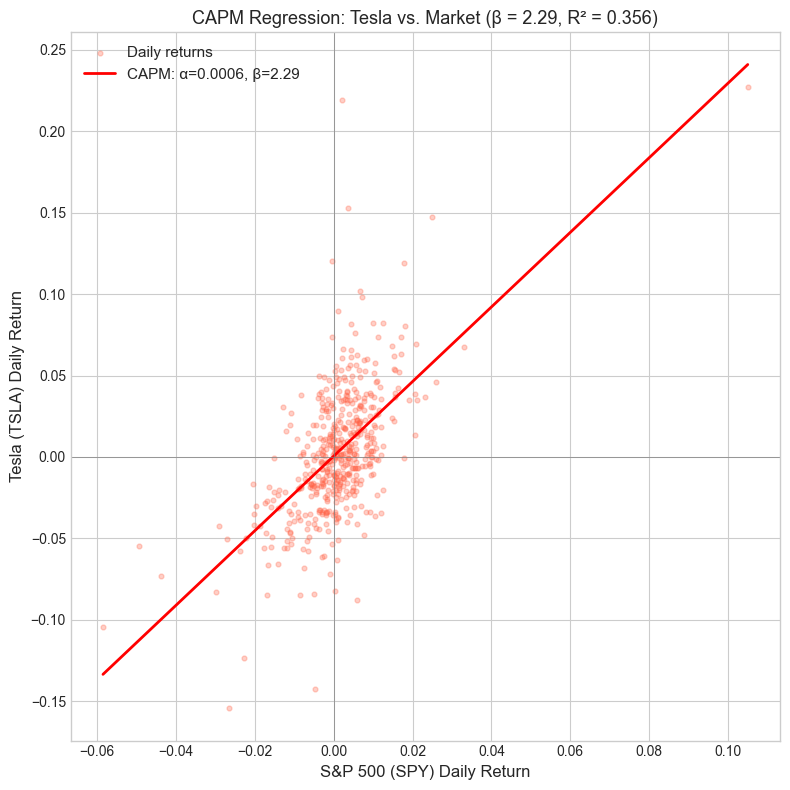

In [21]:
# 1. Download your chosen stock (period='2y')
tsla = yf.download('TSLA', period='2y')

# 2. Flatten MultiIndex columns
tsla.columns = tsla.columns.get_level_values(0)

# 3. Calculate daily returns
tsla['Return'] = tsla['Close'].pct_change()

# 4. Merge with spy returns
merged_ex1 = pd.DataFrame({
    'TSLA': tsla['Return'],
    'SPY': spy['Return']
}).dropna()

print(f"Matched trading days: {len(merged_ex1)}")

# 5. Run linregress to get beta and alpha
slope_ex1, intercept_ex1, r_value_ex1, p_value_ex1, std_err_ex1 = stats.linregress(
    merged_ex1['SPY'], merged_ex1['TSLA']
)

beta_ex1         = slope_ex1
alpha_daily_ex1  = intercept_ex1
alpha_annual_ex1 = alpha_daily_ex1 * 252
r_squared_ex1    = r_value_ex1 ** 2

# 6. Print results and interpret
print("\nCAPM Regression: Tesla (TSLA) vs. S&P 500")
print("=" * 50)
print(f"Beta:               {beta_ex1:.3f}")
print(f"Alpha (daily):      {alpha_daily_ex1:.6f} ({alpha_daily_ex1 * 100:.4f}%)")
print(f"Alpha (annualized): {alpha_annual_ex1:.4f} ({alpha_annual_ex1 * 100:.2f}%)")
print(f"R-squared:          {r_squared_ex1:.3f}")
print(f"p-value (beta):     {p_value_ex1:.2e}")
print()

if beta_ex1 > 1:
    print(f"Beta = {beta_ex1:.2f} > 1: Tesla is MORE volatile than the market.")
    print(f"When the market moves 1%, Tesla tends to move {beta_ex1:.2f}%.")
elif beta_ex1 < 1:
    print(f"Beta = {beta_ex1:.2f} < 1: Tesla is LESS volatile than the market.")
    print(f"When the market moves 1%, Tesla tends to move {beta_ex1:.2f}%.")
else:
    print(f"Beta ≈ 1: Tesla moves roughly in line with the market.")

print(f"\nR-squared = {r_squared_ex1:.3f}: The market explains {r_squared_ex1*100:.1f}% of Tesla's return variation.")
print(f"The remaining {(1-r_squared_ex1)*100:.1f}% is company-specific (idiosyncratic) risk.")

if alpha_annual_ex1 > 0:
    print(f"\nPositive alpha of {alpha_annual_ex1*100:.2f}% per year — Tesla earned excess returns beyond CAPM.")
else:
    print(f"\nNegative alpha of {alpha_annual_ex1*100:.2f}% per year — Tesla underperformed relative to its risk.")

# Scatter plot with regression line
plt.figure(figsize=(8, 8))
plt.scatter(merged_ex1['SPY'], merged_ex1['TSLA'], alpha=0.3, s=12, color='tomato', label='Daily returns')

x_line_ex1 = np.linspace(merged_ex1['SPY'].min(), merged_ex1['SPY'].max(), 100)
y_line_ex1 = intercept_ex1 + beta_ex1 * x_line_ex1
plt.plot(x_line_ex1, y_line_ex1, 'r-', linewidth=2,
         label=f'CAPM: α={alpha_daily_ex1:.4f}, β={beta_ex1:.2f}')

plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.xlabel('S&P 500 (SPY) Daily Return', fontsize=12)
plt.ylabel('Tesla (TSLA) Daily Return', fontsize=12)
plt.title(f'CAPM Regression: Tesla vs. Market (β = {beta_ex1:.2f}, R² = {r_squared_ex1:.3f})', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Exercise 2: Option Payoff for a Straddle

A **straddle** is when you buy BOTH a call AND a put at the same strike price. You profit when the stock makes a big move in *either* direction.

Plot the payoff diagram for a straddle with strike = $180, call premium = $5, put premium = $4.

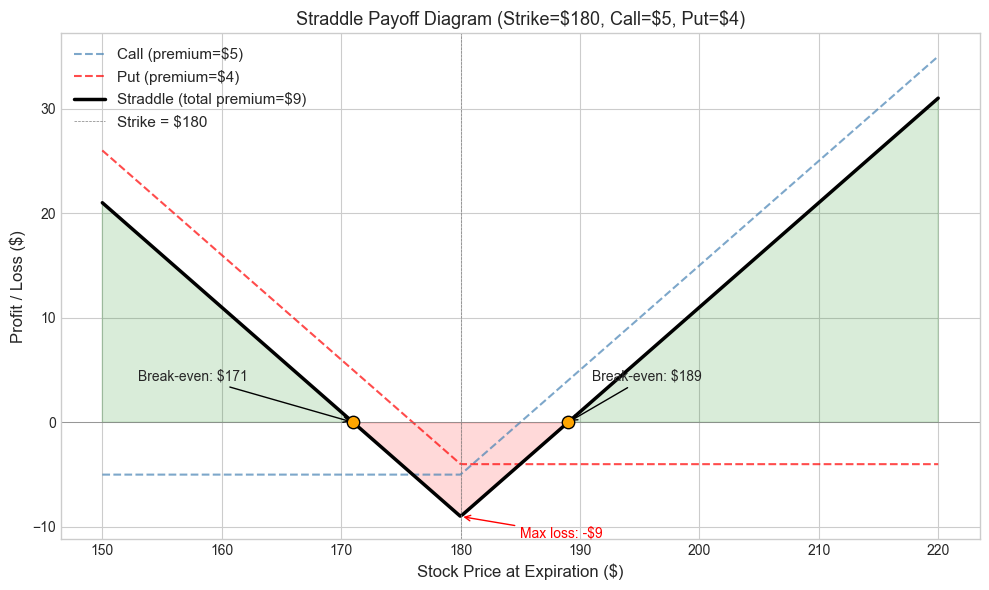

Straddle Strategy Summary:
  Total premium paid:   $9
  Max loss:             -$9 (if stock stays exactly at $180)
  Upper break-even:     $189 (stock must rise above this to profit on the upside)
  Lower break-even:     $171 (stock must fall below this to profit on the downside)

You profit when the stock moves MORE than $9 in either direction.
This strategy bets on HIGH VOLATILITY — a big move regardless of direction.


In [22]:
# Total premium = call_premium + put_premium
# You profit when the stock moves more than the total premium in either direction
strike = 180
call_premium = 5
put_premium = 4
total_premium = call_premium + put_premium

prices = np.linspace(150, 220, 300)

call_payoff = np.maximum(prices - strike, 0) - call_premium
put_payoff = np.maximum(strike - prices, 0) - put_premium

# Straddle = buy call + buy put at same strike
straddle_payoff = call_payoff + put_payoff

breakeven_up = strike + total_premium
breakeven_down = strike - total_premium

plt.figure(figsize=(10, 6))
plt.plot(prices, call_payoff, '--', color='steelblue', linewidth=1.5, alpha=0.7, label=f'Call (premium=${call_premium})')
plt.plot(prices, put_payoff, '--', color='red', linewidth=1.5, alpha=0.7, label=f'Put (premium=${put_premium})')
plt.plot(prices, straddle_payoff, 'k-', linewidth=2.5, label=f'Straddle (total premium=${total_premium})')

plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=strike, color='gray', linewidth=0.5, linestyle='--', label=f'Strike = ${strike}')

plt.fill_between(prices, straddle_payoff, 0, where=(straddle_payoff > 0), alpha=0.15, color='green')
plt.fill_between(prices, straddle_payoff, 0, where=(straddle_payoff < 0), alpha=0.15, color='red')

# Annotate break-even points
plt.scatter([breakeven_up, breakeven_down], [0, 0], s=80, color='orange', zorder=5, edgecolor='black')
plt.annotate(f'Break-even: ${breakeven_up}', xy=(breakeven_up, 0),
             xytext=(breakeven_up + 2, 4), fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate(f'Break-even: ${breakeven_down}', xy=(breakeven_down, 0),
             xytext=(breakeven_down - 18, 4), fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f'Max loss: -${total_premium}', xy=(strike, -total_premium),
             xytext=(strike + 5, -total_premium - 2), fontsize=10, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('Stock Price at Expiration ($)', fontsize=12)
plt.ylabel('Profit / Loss ($)', fontsize=12)
plt.title(f'Straddle Payoff Diagram (Strike=${strike}, Call=${call_premium}, Put=${put_premium})', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Straddle Strategy Summary:")
print(f"  Total premium paid:   ${total_premium}")
print(f"  Max loss:             -${total_premium} (if stock stays exactly at ${strike})")
print(f"  Upper break-even:     ${breakeven_up} (stock must rise above this to profit on the upside)")
print(f"  Lower break-even:     ${breakeven_down} (stock must fall below this to profit on the downside)")
print(f"\nYou profit when the stock moves MORE than ${total_premium} in either direction.")
print(f"This strategy bets on HIGH VOLATILITY — a big move regardless of direction.")

### Exercise 3: Test Normality for a Different Stock

Pick a different stock (or an ETF like `QQQ`, `IWM`, `GLD`) and test whether its returns are normally distributed. Create the histogram, QQ plot, and run the Jarque-Bera test.

[*********************100%***********************]  1 of 1 completed


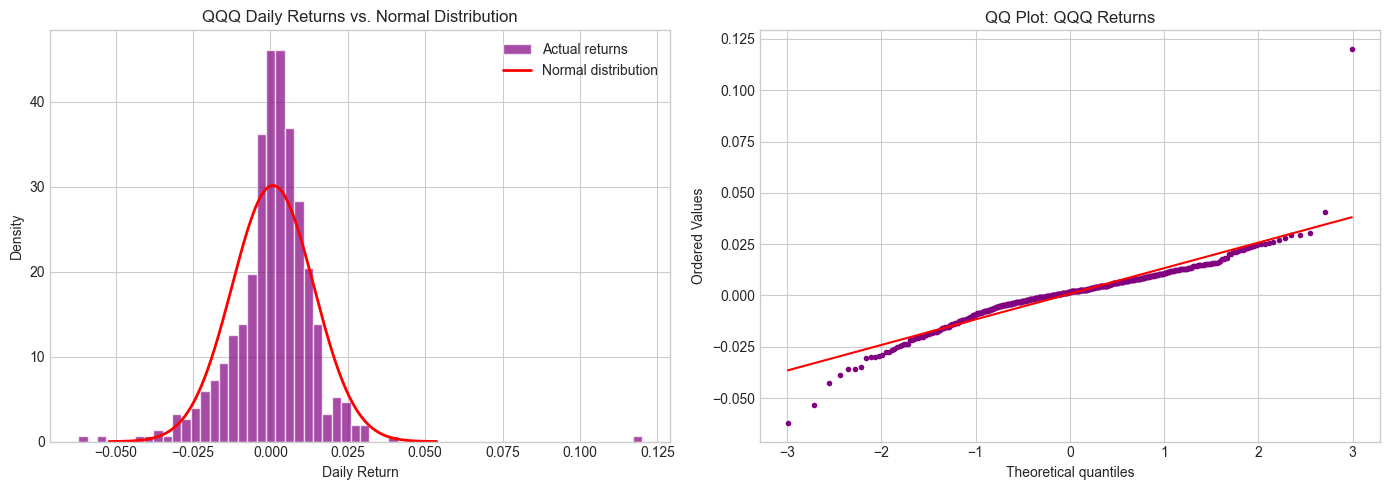

Normality Test: QQQ (Nasdaq 100 ETF)
  Skewness:         0.791  (normal = 0)
  Excess Kurtosis:  14.465  (normal = 0, fat tails > 0)
  Jarque-Bera stat: 4317.12
  p-value:          0.000000
  Conclusion: REJECT normality (p < 0.05) — QQQ returns are NOT normally distributed.

Extreme Events: QQQ Actual vs. Normal Prediction (n=500 days)
Beyond 2 sigma: Normal predicts 22.8, Actually saw 22  (1.0x more than expected)
Beyond 3 sigma: Normal predicts 1.3, Actually saw 5  (3.7x more than expected)
Beyond 4 sigma: Normal predicts 0.0, Actually saw 3  (94.7x more than expected)


In [23]:
# Exercise 3: Test Normality for QQQ (Nasdaq 100 ETF)

qqq = yf.download('QQQ', period='2y')
qqq.columns = qqq.columns.get_level_values(0)
qqq['Return'] = qqq['Close'].pct_change()
qqq_returns = qqq['Return'].dropna()

mu_qqq = qqq_returns.mean()
sigma_qqq = qqq_returns.std()

# --- Histogram vs Normal ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(qqq_returns, bins=60, density=True, color='purple', edgecolor='white', alpha=0.7, label='Actual returns')
x_qqq = np.linspace(mu_qqq - 4*sigma_qqq, mu_qqq + 4*sigma_qqq, 200)
axes[0].plot(x_qqq, stats.norm.pdf(x_qqq, mu_qqq, sigma_qqq), 'r-', linewidth=2, label='Normal distribution')
axes[0].set_title('QQQ Daily Returns vs. Normal Distribution', fontsize=12)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# --- QQ Plot ---
stats.probplot(qqq_returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot: QQQ Returns', fontsize=12)
axes[1].get_lines()[0].set_color('purple')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

# --- Jarque-Bera Test ---
skew_qqq = qqq_returns.skew()
kurt_qqq = qqq_returns.kurtosis()
jb_stat_qqq, jb_pval_qqq = stats.jarque_bera(qqq_returns)

print("Normality Test: QQQ (Nasdaq 100 ETF)")
print("=" * 50)
print(f"  Skewness:         {skew_qqq:.3f}  (normal = 0)")
print(f"  Excess Kurtosis:  {kurt_qqq:.3f}  (normal = 0, fat tails > 0)")
print(f"  Jarque-Bera stat: {jb_stat_qqq:.2f}")
print(f"  p-value:          {jb_pval_qqq:.6f}")
if jb_pval_qqq < 0.05:
    print(f"  Conclusion: REJECT normality (p < 0.05) — QQQ returns are NOT normally distributed.")
else:
    print(f"  Conclusion: Cannot reject normality (p >= 0.05).")

# --- Extreme events ---
n_qqq = len(qqq_returns)
print(f"\nExtreme Events: QQQ Actual vs. Normal Prediction (n={n_qqq} days)")
print("=" * 55)
for n_sigma in [2, 3, 4]:
    actual_qqq = ((qqq_returns > mu_qqq + n_sigma * sigma_qqq) | 
                  (qqq_returns < mu_qqq - n_sigma * sigma_qqq)).sum()
    expected_pct_qqq = 2 * (1 - stats.norm.cdf(n_sigma))
    expected_qqq = expected_pct_qqq * n_qqq
    print(f"Beyond {n_sigma} sigma: Normal predicts {expected_qqq:.1f}, Actually saw {actual_qqq}  "
          f"({actual_qqq/expected_qqq:.1f}x more than expected)")


---

## Part 7: Prompt Engineering

Now use AI to help interpret what you've learned.

### Exercise 4: Interpret Your CAPM Results

Take the beta and alpha values you calculated (either for Apple or your chosen stock) and write a prompt asking an AI to explain what they mean in plain English.

**Include the actual numbers.** A good prompt might also ask: "What would this mean for a portfolio manager?" or "How does this compare to the average stock?"

```
YOUR PROMPT HERE:
I ran a CAPM regression of Tesla (TSLA) daily returns against the S&P 500 (SPY)
over the past 2 years and got the following results:

  - Beta:               2.289
  - Alpha (annualized): 14.28%
  - R-squared:          0.356

Please explain what each of these numbers means in plain English.

```

**AI Response:** (Paste response here)

```

Beta: 2.289
Tesla moves roughly 2.3% for every 1% move in the S&P 500. For a portfolio manager, this means TSLA carries more than twice the systematic (market) risk of an average stock. If the market drops 20% in a bear market, your CAPM-predicted loss on TSLA alone would be around 46% — before any company-specific factors. This has direct implications for position sizing: to hold the same risk-equivalent exposure as a typical stock, you'd need to roughly halve your TSLA position size relative to your other holdings. It also means the stock is a poor hedge against anything — it amplifies market moves in both directions.
Alpha: +14.28% annualized
This is the return Tesla delivered above and beyond what its beta exposure would have predicted. A positive 14.28% annualized alpha is large and economically meaningful on its face — over two years, that's a substantial edge. But you need to pressure-test it before getting excited:

Check the t-statistic. With ~500 trading days, you have reasonable statistical power, but equity return noise is high. If the t-stat on your alpha is below ~2.0, it may not be distinguishable from zero at conventional confidence levels. Given two years is a relatively short window, I'd treat this with some caution until you verify significance.
Consider the period. TSLA had a significant recovery rally in late 2023 and periods of sharp outperformance. A two-year window ending recently may be capturing a specific phase of Tesla's story rather than a persistent structural alpha.
Survivorship and look-ahead. You chose to study TSLA because it's interesting — stocks that generate attention often do so because they had unusual returns. That introduces a mild selection bias.

The bottom line: the alpha is large enough to be economically interesting, but two years isn't long enough to confidently call it persistent. It's a signal worth noting, not a conclusion.
R-squared: 0.356
Only about 36% of Tesla's daily return variance is explained by the S&P 500's movement. The remaining 64% comes from company-specific factors — earnings, delivery numbers, margin announcements, regulatory news, Elon Musk's public activity, and so on. This is actually quite low for a mega-cap stock. Apple and Microsoft, deeply embedded in the index, typically show R² values of 0.60–0.75.
What this means practically: TSLA is difficult to hedge with index instruments. If you short SPY to offset your TSLA exposure, you're only neutralizing about a third of the risk. The rest is naked idiosyncratic exposure that no market hedge will cover. For a portfolio manager, this cuts both ways — that idiosyncratic variance is what generated the positive alpha above, but it's also what could generate sharp, unpredictable losses that have nothing to do with the broader market.

Compared to an average stock
MetricAverage StockTesla (yours)InterpretationBeta~1.02.2892.3× the market sensitivityAlpha~0%+14.28%Strong outperformance on risk-adj. basisR²~0.3–0.60.356Low — mostly idiosyncratic
Taken together, your regression is describing a stock that swings hard with the market (high beta), has delivered meaningful risk-adjusted outperformance over this window (positive alpha), but is mostly dancing to its own drummer rather than the market's tune (low R²). That combination — high beta, positive alpha, low R² — is characteristic of a high-conviction, high-volatility growth story where company-specific execution has mattered far more than macro tailwinds. Whether that continues depends entirely on Tesla's fundamentals, not the market.

```

**Your evaluation:** Was the response accurate given what you learned today?
Yes